# Supp. Fig. 32 — Senescent-Hepatocyte DESeq2 Module Score (All Donors)

**Purpose:** Score every sample's hepatocytes for a "high-fibrosis senescent
hepatocyte" gene module (top 50 DESeq2 genes by p-value and by log2FC,
comparing Hepatocytes.Senescent in high-fibrosis vs. control), label
high-scoring cells, and save per-sample spatial plots + labeled `.h5ad`
files. This is the "clean, parametrized" version of the pipeline — the
core loop (cells under **Per-sample pipeline** / **Run the pipeline for
every sample**) already ran cleanly across all three donors.

The remainder of the notebook (**Exploratory analysis**) is one-off,
single-sample follow-up work built on top of that pipeline's output; it was
left less polished in the original and has been lightly cleaned below
(removed dead/broken scratch cells) rather than fully restructured, since it
isn't the parametrized part of the pipeline.

**Cleanup notes (this pass):** in the exploratory section, removed several
redundant re-computations of the same intermediate object, two syntactically
broken cells (stray leading indentation) that also referenced an undefined
column, an unsaved duplicate spatial plot, and a couple of empty cells.

## Setup

In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt


## Parameters

`sample_nm_list` holds every spatial sample to process. Each sample's tangram run lives under a different base directory, so `sample_to_inp_dir` maps `sample_nm -> inp_dir`.

In [2]:
# ---- Parameter cell ----
# Every sample below will be run through the pipeline in the loop further down.
# Each sample_nm maps to the tangram run directory it lives under:
#   'HL170058_filt'   -> deep_seq_heps_alldonors_highfib_lowfib
#   'HL230324_filt'   -> deep_seq_heps_alldonors_ds10k_ref
#   'HL160029_filt'   -> deep_seq_heps_alldonors_ds10k_ref
sample_nm_list = ['HL170058_filt', 'HL230324_filt', 'HL160029_filt']

sample_to_inp_dir = {
    'HL170058_filt': '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/tangram/deep_seq_heps_alldonors_highfib_lowfib/',
    'HL230324_filt': '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/tangram/deep_seq_heps_alldonors_ds10k_ref/',
    'HL160029_filt': '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/tangram/deep_seq_heps_alldonors_ds10k_ref/',
}


In [3]:
# All figures and the output .h5ad for every sample are written here (same
# directory for everything, per-file names carry the sample_nm suffix).
odir = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/RNA/clusterprofiler_kegg_react/top_deseq2_genes_all_samples/'
os.makedirs(odir, exist_ok=True)


## DESeq2 gene sets (sample-independent)

These come from the Hepatocyte high-fibrosis-senescent vs. control DESeq2 result and don't depend on `sample_nm`, so they're computed once and reused for every sample in the loop below.

In [4]:
highfib_res = pd.read_csv(
    '/tscc/lustre/ddn/scratch/welison/Liver_Share/result.depot/250131_Hepatocyte_Subtype_DESeq/RNA/Hepatocytes.Senescent_High_Fibrosis_vs_Control.dds.res',
    sep="\t",
)

# Significant, up-regulated genes
highfib_res_up = highfib_res[(highfib_res['padj'] < 0.1) & (highfib_res['log2FoldChange'] > 2)]
highfib_res_up_fc = highfib_res_up.sort_values(by='log2FoldChange', ascending=False)


In [5]:
# Top 50 genes by p-value
hf_list_50 = highfib_res_up.index.tolist()[:50]
hf_list_50_lc = [gene.lower() for gene in hf_list_50]

# Top 50 genes by log2FoldChange
hf_fc_list_50 = highfib_res_up_fc.index.tolist()[:50]
hf_fc_list_50_lc = [gene.lower() for gene in hf_fc_list_50]

score_name = "RNA_sen_highfib_deseq_top50_pval_rna_multiome"
score_name_fc = "RNA_sen_highfib_deseq_top50_log2fc_rna_multiome"

fc_colors = {
    "High_Score": "#FF0000",  # Red for high fold change
    "Low_Score": "#0000FF",   # Blue for low fold change
}


In [6]:
# Gene list is the same for every sample, so it's written once (no sample_nm needed).
file_name = "RNA_sen_highfib_deseq_top50_log2fc_rna_multiome.txt"
whole_file_name = f"{odir}{file_name}"

with open(whole_file_name, "w") as f:
    for item in hf_fc_list_50:
        f.write(item + "\n")

print(f"List successfully written to {whole_file_name}")


List successfully written to /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/RNA/clusterprofiler_kegg_react/top_deseq2_genes_all_samples/RNA_sen_highfib_deseq_top50_log2fc_rna_multiome.txt


## Per-sample pipeline

`process_sample` runs the full scoring / labeling / figure-saving pipeline for one `sample_nm` and writes its labeled `.h5ad` to `odir`. It's called once per sample in the loop below.

In [7]:
def process_sample(sample_nm):
    """Score, label, and plot one spatial sample; write the labeled .h5ad to odir.

    Returns the final AnnData object for this sample.
    """
    # --- load ---
    inp_dir = sample_to_inp_dir[sample_nm]
    sp_file_path = os.path.join(inp_dir, sample_nm, 'merge/Post_sp_ct_proj_comb_outer.h5ad')
    adata_pred_filt_cropped = sc.read_h5ad(sp_file_path)
    print(f"[{sample_nm}] loaded: {adata_pred_filt_cropped.shape[0]} obs x {adata_pred_filt_cropped.shape[1]} vars")

    # --- module scores from the DESeq2 gene sets ---
    sc.tl.score_genes(adata_pred_filt_cropped, gene_list=hf_list_50_lc, score_name=score_name)
    sc.tl.score_genes(adata_pred_filt_cropped, gene_list=hf_fc_list_50_lc, score_name=score_name_fc)

    # p-value-ranked score, spatial plot
    plt.style.use('dark_background')
    sc.pl.spatial(
        adata_pred_filt_cropped,
        color=score_name,
        color_map="inferno",
        show=False,
        size=4,
        img_key=None,
    )
    plt.savefig(f"{odir}{score_name}_{sample_nm}.pdf")
    plt.close()

    # log2FC-ranked score, spatial plot
    plt.style.use('dark_background')
    sc.pl.spatial(
        adata_pred_filt_cropped,
        color=score_name_fc,
        color_map="inferno",
        show=False,
        size=4,
        img_key=None,
    )
    plt.savefig(f"{odir}{score_name_fc}_{sample_nm}.pdf")
    plt.close()

    # same score, fixed color scale (vmax=0.2) so samples are comparable
    plt.style.use('dark_background')
    sc.pl.spatial(
        adata_pred_filt_cropped,
        color=score_name_fc,
        color_map="inferno",
        show=False,
        size=4,
        img_key=None,
        vmax=0.2,
    )
    plt.savefig(f"{odir}{score_name_fc}_scales_{sample_nm}.pdf")
    plt.close()

    # --- pt02_score: label cells with score_name_fc > 0.02 ---
    adata_pred_filt_cropped.obs["pt02_score"] = np.where(
        adata_pred_filt_cropped.obs[score_name_fc] > 0.02, "High_Score", "Low_Score"
    )

    plt.style.use('dark_background')
    sc.pl.spatial(
        adata_pred_filt_cropped,
        color='pt02_score',
        color_map="inferno",
        palette=fc_colors,
        show=False,
        size=4,
        img_key=None,
    )
    plt.savefig(f"{odir}all_pt02_score_{sample_nm}.pdf")
    plt.close()

    plt.style.use('dark_background')
    sc.pl.spatial(
        adata_pred_filt_cropped[adata_pred_filt_cropped.obs.sort_values("pt02_score", ascending=False).index],
        color='pt02_score',
        color_map="inferno",
        palette=fc_colors,
        show=False,
        size=4,
        img_key=None,
    )
    plt.savefig(f"{odir}all_pt02_score_top_{sample_nm}.pdf")
    plt.close()

    # --- pt01_score: label cells with score_name_fc > 0.01 ---
    adata_pred_filt_cropped.obs["pt01_score"] = np.where(
        adata_pred_filt_cropped.obs[score_name_fc] > 0.01, "High_Score", "Low_Score"
    )

    plt.style.use('dark_background')
    sc.pl.spatial(
        adata_pred_filt_cropped,
        color='pt01_score',
        color_map="inferno",
        palette=fc_colors,
        show=False,
        size=4,
        img_key=None,
    )
    plt.savefig(f"{odir}all_pt01_score_{sample_nm}.pdf")
    plt.close()

    plt.style.use('dark_background')
    sc.pl.spatial(
        adata_pred_filt_cropped[adata_pred_filt_cropped.obs.sort_values("pt01_score", ascending=False).index],
        color='pt01_score',
        color_map="inferno",
        palette=fc_colors,
        show=False,
        size=4,
        img_key=None,
    )
    plt.savefig(f"{odir}all_pt01_score_top_{sample_nm}.pdf")
    plt.close()

    # --- relabel senescent hepatocytes with a "high score" subtype ---
    target_cells = ['Hepatocytes.Senescent']

    adata_pred_filt_cropped.obs['celltype_proj_heps_pt01'] = adata_pred_filt_cropped.obs.apply(
        lambda row: 'Hepatocytes.Senescent.High'
        if row['pt01_score'] == 'High_Score' and row['celltype_proj'] in target_cells
        else row['celltype_proj'],
        axis=1,
    )

    adata_pred_filt_cropped.obs['celltype_proj_heps_pt02'] = adata_pred_filt_cropped.obs.apply(
        lambda row: 'Hepatocytes.Senescent.High'
        if row['pt02_score'] == 'High_Score' and row['celltype_proj'] in target_cells
        else row['celltype_proj'],
        axis=1,
    )

    print(f"[{sample_nm}] pt01_score:\n{adata_pred_filt_cropped.obs['pt01_score'].value_counts()}")
    print(f"[{sample_nm}] pt02_score:\n{adata_pred_filt_cropped.obs['pt02_score'].value_counts()}")

    # --- write out (same directory as the figures above) ---
    out_path = f"{odir}adata_heps_score_sencells_labels_{sample_nm}.h5ad"
    adata_pred_filt_cropped.write_h5ad(out_path)
    print(f"[{sample_nm}] wrote {out_path}")

    return adata_pred_filt_cropped


## Run the pipeline for every sample

In [8]:
adata_by_sample = {}
for sample_nm in sample_nm_list:
    adata_by_sample[sample_nm] = process_sample(sample_nm)


[HL170058_filt] loaded: 190195 obs x 18016 vars
       'msc-as1', 'pkn2-as1', 'lyplal1-dt', 'pvt1', 'mir4435-2hg',
       'al590652.1'],
      dtype='object')
       'linc02233', 'znf385d-as2', 'linc02477', 'al807761.4', 'dlgap1-as3',
       'linc02006', 'ap000851.1'],
      dtype='object')


/scratch/cmiciano/job_12303658/ipykernel_207694/1582486754.py:18: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/scratch/cmiciano/job_12303658/ipykernel_207694/1582486754.py:31: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/scratch/cmiciano/job_12303658/ipykernel_207694/1582486754.py:44: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/scratch/cmiciano/job_12303658/ipykernel_207694/1582486754.py:62: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/scratch/cmiciano/job_12303658/ipykernel_207694/1582486754.py:75: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/scanpy/plotting/_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/scratch/cmiciano/job_12303658/ipyker

[HL170058_filt] pt01_score:
pt01_score
Low_Score     181925
High_Score      8270
Name: count, dtype: int64
[HL170058_filt] pt02_score:
pt02_score
Low_Score     183821
High_Score      6374
Name: count, dtype: int64
[HL170058_filt] wrote /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/RNA/clusterprofiler_kegg_react/top_deseq2_genes_all_samples/adata_heps_score_sencells_labels_HL170058_filt.h5ad
[HL230324_filt] loaded: 197933 obs x 17687 vars
       'msc-as1', 'pkn2-as1', 'lyplal1-dt', 'pvt1', 'mir4435-2hg',
       'al590652.1'],
      dtype='object')
       'linc02233', 'znf385d-as2', 'linc02477', 'al807761.4', 'dlgap1-as3',
       'linc02006', 'ap000851.1'],
      dtype='object')


/scratch/cmiciano/job_12303658/ipykernel_207694/1582486754.py:18: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/scratch/cmiciano/job_12303658/ipykernel_207694/1582486754.py:31: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/scratch/cmiciano/job_12303658/ipykernel_207694/1582486754.py:44: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/scratch/cmiciano/job_12303658/ipykernel_207694/1582486754.py:62: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/scratch/cmiciano/job_12303658/ipykernel_207694/1582486754.py:75: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/scanpy/plotting/_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/scratch/cmiciano/job_12303658/ipyker

[HL230324_filt] pt01_score:
pt01_score
Low_Score     177711
High_Score     20222
Name: count, dtype: int64
[HL230324_filt] pt02_score:
pt02_score
Low_Score     182726
High_Score     15207
Name: count, dtype: int64
[HL230324_filt] wrote /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/RNA/clusterprofiler_kegg_react/top_deseq2_genes_all_samples/adata_heps_score_sencells_labels_HL230324_filt.h5ad
[HL160029_filt] loaded: 175644 obs x 18006 vars
       'msc-as1', 'pkn2-as1', 'lyplal1-dt', 'pvt1', 'mir4435-2hg',
       'al590652.1'],
      dtype='object')
       'linc02233', 'znf385d-as2', 'linc02477', 'al807761.4', 'dlgap1-as3',
       'linc02006', 'ap000851.1'],
      dtype='object')


/scratch/cmiciano/job_12303658/ipykernel_207694/1582486754.py:18: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/scratch/cmiciano/job_12303658/ipykernel_207694/1582486754.py:31: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/scratch/cmiciano/job_12303658/ipykernel_207694/1582486754.py:44: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/scratch/cmiciano/job_12303658/ipykernel_207694/1582486754.py:62: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/scratch/cmiciano/job_12303658/ipykernel_207694/1582486754.py:75: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/scanpy/plotting/_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/scratch/cmiciano/job_12303658/ipyker

[HL160029_filt] pt01_score:
pt01_score
Low_Score     169001
High_Score      6643
Name: count, dtype: int64
[HL160029_filt] pt02_score:
pt02_score
Low_Score     170353
High_Score      5291
Name: count, dtype: int64
[HL160029_filt] wrote /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/RNA/clusterprofiler_kegg_react/top_deseq2_genes_all_samples/adata_heps_score_sencells_labels_HL160029_filt.h5ad


## Exploratory analysis (single sample)

Everything below is one-off exploration on a *single* sample, not part of the per-sample loop above. It reuses the in-memory result from `adata_by_sample` (no need to re-read the .h5ad from disk). Change `sample_nm` here to explore a different sample.

In [ ]:
# ---- Choose which already-processed sample to explore below ----
sample_nm = sample_nm_list[0]

test = adata_by_sample[sample_nm]
test


In [ ]:
test.obs['celltype_proj_heps_pt01'].value_counts()


In [ ]:
test.obs['celltype_proj_heps_pt02'].value_counts()


In [ ]:
test.obs["pt01_score"].value_counts()


In [ ]:
test.obs["pt02_score"].value_counts()


In [ ]:
# Color palette for broad + hepatocyte-subtype cell types.
# Defined here for potential downstream spatial plots; not otherwise used
# further in this notebook.
neon_rainbow_colors_broad = {
    'Myeloid': '#0000FF',              # Neon blue
    'T_NK': '#FFFA00',                 # Neon yellow
    'Cholangiocyte': '#00FF00',        # Neon green
    'HSC': '#00FFFF',                  # Neon cyan
    'Endothelial': '#8A2BE2',          # Neon purple
    'NK': '#FFFDBB',                   # Lighter yellow
    'B': '#FF8800',                    # Neon hot pink
    'Hepatocytes.Zone1': '#FF007F',    # Neon pink
    'Hepatocytes.Zone2': '#FF6600',    # Neon orange
    'Hepatocytes.Zone3': '#99FF00',    # Lime green
    'Hepatocytes.Senescent.High': '#9B00FF',
    'Hepatocytes.Senescent': '#00FF00',
    'Hepatocytes.Stress': '#00FFFF',
}


In [ ]:
# Full spatial object this sample's tangram predictions came from (separate
# from the tangram merge outputs used in the loop above).
adata = sc.read_h5ad(
    f'/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/misc/tangram_scores_dist2/{sample_nm}/adata_0.5_tangram_filt.h5ad'
)
full_adata = adata.copy()


In [ ]:
# Map the hepatocyte pt01/pt02 subtype labels from `test` back onto full_adata
hepatocyte_mapping = test.obs['celltype_proj_heps_pt01'].to_dict()
full_adata.obs['celltype_proj_heps_pt01'] = full_adata.obs.index.map(hepatocyte_mapping)

full_adata.obs['celltype_proj_heps_pt01'] = full_adata.obs['celltype_proj_heps_pt01'].astype(str)
full_adata.obs['pred_cell_types'] = full_adata.obs['pred_cell_types'].astype(str)
full_adata.obs['celltype_proj_heps_pt01'] = full_adata.obs['celltype_proj_heps_pt01'].fillna(
    full_adata.obs['pred_cell_types']
)
full_adata.obs['celltype_proj_heps_pt01'] = full_adata.obs['celltype_proj_heps_pt01'].astype("category")

full_adata.obs[['pred_cell_types', 'celltype_proj_heps_pt01']].head()


In [ ]:
full_adata.obs['celltype_proj_heps_pt01'].value_counts()


Subset to the cell types of interest for a (not-yet-included) follow-on neighborhood-enrichment analysis. Only the final subset definition below is kept; the notebook does not go on to run that analysis.

In [ ]:
# Directory used for the neighborhood-analysis outputs below (separate from
# the clusterprofiler odir used in the per-sample loop above).
neighborhood_odir = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/neighborhood_analysis/high_score_sen_cells_mash_fib2/'
os.makedirs(neighborhood_odir, exist_ok=True)


In [ ]:
# Same mapping, using the pt02 (0.02 threshold) subtype labels instead
hepatocyte_mapping = test.obs['celltype_proj_heps_pt02'].to_dict()
full_adata.obs['celltype_proj_heps_pt02'] = full_adata.obs.index.map(hepatocyte_mapping)

full_adata.obs['celltype_proj_heps_pt02'] = full_adata.obs['celltype_proj_heps_pt02'].astype(str)
full_adata.obs['celltype_proj_heps_pt02'] = full_adata.obs['celltype_proj_heps_pt02'].fillna(
    full_adata.obs['pred_cell_types']
)
full_adata.obs['celltype_proj_heps_pt02'] = full_adata.obs['celltype_proj_heps_pt02'].astype("category")

full_adata.obs[['pred_cell_types', 'celltype_proj_heps_pt02']].head()


In [ ]:
# Subset to only the two cell types of interest for downstream neighborhood analysis
heps_subset = full_adata[full_adata.obs['celltype_proj_heps_pt02'].isin(
    ["Hepatocytes.Zone3", "Hepatocytes.Senescent.High"]
)].copy()


## Single-sample custom-threshold examples

/scratch/cmiciano/job_12303658/ipykernel_207694/3153324989.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


[<Axes: title={'center': 'pt02_score_custom'}, xlabel='spatial1', ylabel='spatial2'>]

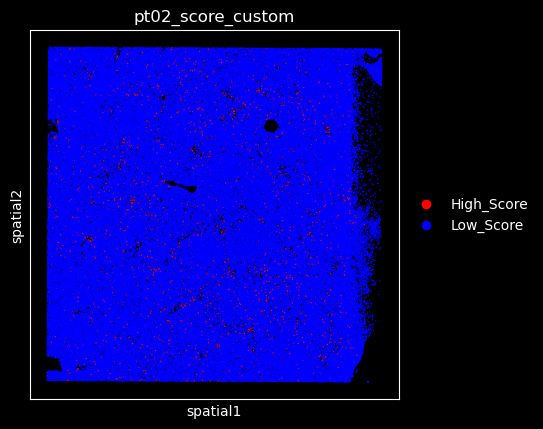

In [10]:
sample_nm = 'HL230324_filt'
adata_hl230324 = sc.read_h5ad(f"{odir}adata_heps_score_sencells_labels_{sample_nm}.h5ad")

custom_threshold = 0.05
adata_hl230324.obs["pt02_score_custom"] = np.where(
    adata_hl230324.obs[score_name_fc] > custom_threshold, "High_Score", "Low_Score"
)

plt.style.use('dark_background')
sc.pl.spatial(
    adata_hl230324,
    color='pt02_score_custom',
    color_map="inferno",
    palette=fc_colors,
    show=False,
    size=4,
    img_key=None,
)
plt.savefig(f"{odir}all_pt02_score_custom_{sample_nm}.pdf")


/scratch/cmiciano/job_12303658/ipykernel_207694/1290628647.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


[<Axes: title={'center': 'pt02_score_custom'}, xlabel='spatial1', ylabel='spatial2'>]

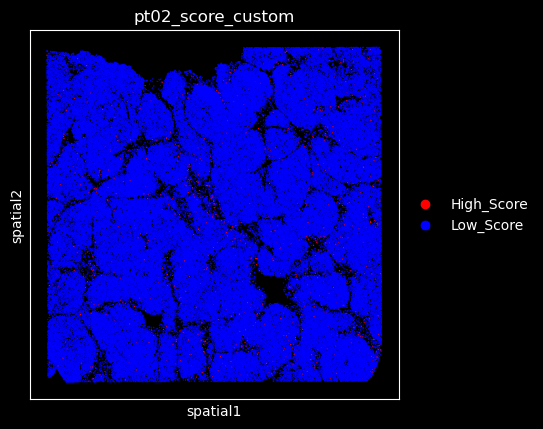

In [14]:
sample_nm = 'HL170058_filt'
adata_HL170058 = sc.read_h5ad(f"{odir}adata_heps_score_sencells_labels_{sample_nm}.h5ad")

custom_threshold = 0.05
adata_HL170058.obs["pt02_score_custom"] = np.where(
    adata_HL170058.obs[score_name_fc] > custom_threshold, "High_Score", "Low_Score"
)

plt.style.use('dark_background')
sc.pl.spatial(
    adata_HL170058,
    color='pt02_score_custom',
    color_map="inferno",
    palette=fc_colors,
    show=False,
    size=4,
    img_key=None,
)
# Not saved for this sample in the original run (kept unsaved here too).


In [17]:
adata_HL170058

AnnData object with n_obs × n_vars = 190195 × 18016
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types', 'RNA_sen_highfib_deseq_top50_pval_rna_multiome', 'RNA_sen_highfib_deseq_top50_log2fc_rna_multiome', 'pt02_score', 'pt01_score', 'celltype_proj_heps_pt01', 'celltype_proj_heps_pt02', 'pt02_score_custom'
    uns: 'pt01_score_colors', 'pt02_score_colors', 'spatial', 'pt02_score_custom_colors'
    obsm: 'spatial', 'spatial_cropped', 'tangram_ct_pred'